In [ ]:
# [1] ResNet (Original Paper)
# K. He, X. Zhang, S. Ren, and J. Sun, "Deep residual learning for image recognition," in Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR), 2016, pp. 770–778.
# [2] Waste Dataset Paper
# A. Yudin, A. V. Savchenko, and A. A. Ivanov, "Hierarchical waste detection with weakly supervised segmentation in images from recycling plants," Engineering Applications of Artificial Intelligence, vol. 130, 2024.
#
# Section 2 — Transfer Learning, Optimisation, Regularisation
# [3] Transfer Learning — ImageNet Models Transferability
# S. Kornblith, J. Shlens, and Q. V. Le, "Do better ImageNet models transfer better?," in Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR), 2019, pp. 2661–2671.
# [4] ULMFiT (Fine‑Tuning Strategy Inspiration)
# J. Howard and S. Ruder, "Universal language model fine‑tuning for text classification," in Proc. 56th Annu. Meeting Assoc. Comput. Linguistics (ACL), 2018, pp. 328–339.
# [5] AdamW Optimizer
# I. Loshchilov and F. Hutter, "Decoupled weight decay regularization," in Proc. Int. Conf. Learn. Represent. (ICLR), 2019.
# [6] Dropout
# N. Srivastava, G. Hinton, A. Krizhevsky, I. Sutskever, and R. Salakhutdinov, "Dropout: A simple way to prevent neural networks from overfitting," Journal of Machine Learning Research, vol. 15, no. 1, pp. 1929–1958, 2014.
#
# Section 4 — Class Imbalance, Initialisation, Scheduling
# [8] Class Imbalance — Systematic Study
# M. Buda, A. Maki, and M. A. Mazurowski, "A systematic study of the class imbalance problem in convolutional neural networks," Neural Networks, vol. 106, pp. 249–259, 2018.
# [9] Class‑Balanced Loss
# Y. Cui, M. Jia, T. Lin, Y. Song, and S. Belongie, "Class‑balanced loss based on effective number of samples," in Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR), 2019, pp. 9268–9277.
# [10] SGDR — Cosine Annealing with Warm Restarts
# I. Loshchilov and F. Hutter, "SGDR: Stochastic gradient descent with warm restarts," in Proc. Int. Conf. Learn. Represent. (ICLR), 2017.

# 1: Imports & root detection

In [ ]:
# import the imports.
import sys, time
from pathlib import Path

# scientific and plotting libs.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pytorch and metrics.
import torch
import torch.nn as nn
from sklearn.metrics import (confusion_matrix, f1_score, precision_score, recall_score)

# Project root detection - determine projects dir path (especially useful since we place this code in a subfolder).
# Walks up from the current working directory until it finds the project root (identified using "Pipeline_").
root = Path.cwd()
while not (root / "Pipeline_").exists() and root != root.parent:
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print("Project root:", root)


# load preprocessor and model definition.
from Pipeline_.preprocessor import WaRPPreprocessor
from Models.ResNet50_Optimised import ResNet50_Optimised 


# GPU is used if available - if not use CPU.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# set the seeds (PyTorch, NumPy, and CUDA) for reproducibility.
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Project root: c:\repo\Waste-Classification
Device: cuda


# 2: Hyperparameters

In [ ]:
EPOCHS          = 100         # [3] full fine‑tuning (not freezing) With AdamW On small datasets can benefit from longer training schedules (50–150 epochs).
BATCH_SIZE      = 32          # [1] preprocessor default and ensure acceptable GPU memory usage.
LR              = 1e-4        # [4] canonical fine‑tuning LR for AdamW (Higher disrupts pretrained weights, lower LR slows convergence_
WEIGHT_DECAY    = 1e-4        # [5] standard AdamW regularisation strength (helps prevent overfitting on small datasets).
DROPOUT         = 0.4         # [6] dropout 0.2–0.5 is recommended for FC layers.
NUM_CLASSES     = 28          # [2] number of waste categories in the WaRP‑C dataset.
NUM_WORKERS     = 4           # number of CPU workers (for data loading)

print("Epochs      :", EPOCHS)
print("Batch size  :", BATCH_SIZE)
print("LR          :", LR)
print("Dropout     :", DROPOUT)
print("Num classes :", NUM_CLASSES)
print("Num workers :", NUM_WORKERS)

Epochs      : 100
Batch size  : 32
LR          : 0.0001
Dropout     : 0.4
Num classes : 28
Num workers : 4


# 3: Data pipeline

In [ ]:
# init pre-processor - set WaRP-C (classifier dataset) are the source.
pp = WaRPPreprocessor(
    raw_root       = root / "Dataset/raw/Warp-C",           # path to WaRP-C images
    processed_root = root / "Dataset/processed",            # path to 28-class processed dataset
    stats_file     = root / "Dataset/dataset_stats.json",   # cached dataset statistics (for normalisation)
    batch_size     = BATCH_SIZE,                            # dataloader batch size
    num_workers    = NUM_WORKERS                            # number of CPU workers (for data loading)
)

# pull model train and test loaders from the preprocessor.
# applies augmentation & resizing pipeline for the given model.
train_loader, test_loader = pp.get_loaders(model_type="resnet50")

# pull all dataset class names.
CLASS_NAMES = sorted(d.name for d in (root / "Dataset/processed/train").iterdir() if d.is_dir())

# print to console.
print(f"Classes       : {len(CLASS_NAMES)}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

[get_loaders] model='resnet50'
  sampler=True  minority_aug=True  mixup=False  pipeline='pretrained_cnn'
  train=273 batches  test=49 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 273
Test  batches : 49


# 4: Loss, model, optimiser, scheduler

In [ ]:
# weighted cross-entropy - The preprocessor calculates inverse-frequency weights
# Ref [8][9]
class_weights = pp.get_class_weights(device=DEVICE)
# cross-entropy loss (standard for CNNs also, adding class weights helps stabilise training on imbalanced data).
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Loss: CrossEntropyLoss + class weights")

# Instantiate ResNet50_Optimised as defined in the ResNet50_Optimised.py file.
# enhanced variant includes: refined classifier head, improved dropout, optional backbone freezing (not used)
# freeze == false ensure backbone layers are trainable for a full fine-tuning setup.
# Ref [10]
model = ResNet50_Optimised(num_classes = NUM_CLASSES, dropout = DROPOUT, freeze_backbone = False).to(DEVICE)

# AdamW used because decoupled weight decay improves generalisation making it more stable for fine-tuning pretrained CNNs
# AdamW fixes Adam's L2 regularisation bug Ref [5]
optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)

# Cosine annealing learning-rate schedule:
# gradually reduces LR following a cosine curve
# Helps avoid getting stuck in sharp minima and improves generalisation.
# [11] introduced cosine annealing 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max  = EPOCHS, eta_min = 1e-7)

# a quick sanity check to ensure the model is on the correct device, input/output shapes are correct & the classifier head is as expected.
with torch.no_grad():                           # disable gradients
    x = torch.zeros(2, 3, 224, 224).to(DEVICE)  # create a dummy batch
    y = model(x)                                # run the model
print("Sanity output:", y.shape)                # output the shape - torch.Size([2, 28]) expected


Loss: CrossEntropyLoss + class weights
Sanity output: torch.Size([2, 28])


# 5: Training loop

In [ ]:
# Features test & removed:
# mix up: no benefit in the results.
# focal loss: outperformed by Xent.
# label smoothing: reduced interpretability - no benefit in the results.
# step LR scheduler: caused abrupt LR changes and produced terrible convergence
# freezing the backbone: out-performed by fine-tuning.
# heavy augmentation: helped when upscaling images to 384px, but harmed results when using 224px
# EMA: added complexity, but didn't improve results.

In [ ]:
# save training loss & accuracy, and test accuracy.
train_losses, train_accs, test_accs = [], [], []
best_acc = 0.0

# Path to save the best model checkpoint
WEIGHTS_PATH = root / "Models/weights/resnet50_optimised_v9_224.pth"

print(f"Starting {EPOCHS} epochs...\n")

# main training loop.
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train() #set training mode (use dropout, batch norm, layer norm)
    ep_loss = correct = total = 0 # reset batch metrics

    # training here.
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        optimizer.zero_grad()               # Reset gradients
        logits = model(imgs)                # Perform forward pass
        loss   = criterion(logits, lbls)    # Computer weighted Xent loss.
        loss.backward()                     # Perform back propagation.
        optimizer.step()                    # Update params (using AdamW)

        # batch metrics (accumulated) - total loss (ep_loss), num of correct predictions correct) and num of samples (total).
        ep_loss += loss.item()
        correct += (logits.argmax(1) == lbls).sum().item()
        total   += lbls.size(0)

    # Scheduler step - updates the learning rate once per epoch
    # large updates early for fast learning, small updates later for fine‑tuning
    scheduler.step()

    # Computer accuracy and loss - epoch level
    train_loss = ep_loss / len(train_loader)
    train_acc  = correct / total * 100

    # Evaluation here (no gradient updates)
    model.eval()                                            # switch to evaluation mode: Disable dropout, freeze batch-norm stats
    correct = total = 0                                     # init counters
    with torch.no_grad():                                   # disable gradients: set inference mode (faster & more memory efficient)
        for imgs, lbls in test_loader:                      # loop over the test set
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()  # perform forward pass, pick the selected class and move predictions to the cpu
            correct += (preds == lbls).sum().item()         # count correct predictions - compare each predicted class with the true label
            total   += lbls.size(0)                         # count total samples
    test_acc = correct / total * 100                        # calculate accuracy

    # save metrics, used for plotting.
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # save best model (is latest accuracy better that the saved best?)
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), WEIGHTS_PATH)
        flag = " ← best"
    else:
        flag = ""

    # print to the console
    print(
        f"Epoch {epoch:3d}/{EPOCHS} | "
        f"loss={train_loss:.4f} | train={train_acc:.2f}% | "
        f"test={test_acc:.2f}% | best={best_acc:.2f}% | "
        f"{time.time()-t0:.1f}s{flag}"
    )


Starting 100 epochs...

Epoch   1/100 | loss=2.1161 | train=19.08% | test=22.89% | best=22.89% | 32.2s ← best
Epoch   2/100 | loss=0.9703 | train=51.21% | test=45.07% | best=45.07% | 17.6s ← best
Epoch   3/100 | loss=0.7089 | train=62.47% | test=54.48% | best=54.48% | 17.6s ← best
Epoch   4/100 | loss=0.5754 | train=68.50% | test=56.48% | best=56.48% | 17.3s ← best
Epoch   5/100 | loss=0.4762 | train=72.22% | test=60.03% | best=60.03% | 17.3s ← best
Epoch   6/100 | loss=0.4521 | train=73.94% | test=61.70% | best=61.70% | 17.4s ← best
Epoch   7/100 | loss=0.3509 | train=78.16% | test=61.90% | best=61.90% | 17.5s ← best
Epoch   8/100 | loss=0.3291 | train=79.97% | test=63.70% | best=63.70% | 17.5s ← best
Epoch   9/100 | loss=0.3123 | train=80.76% | test=64.09% | best=64.09% | 17.7s ← best
Epoch  10/100 | loss=0.2705 | train=81.57% | test=66.73% | best=66.73% | 17.4s ← best
Epoch  11/100 | loss=0.2615 | train=82.76% | test=65.64% | best=66.73% | 17.6s
Epoch  12/100 | loss=0.2383 | train=8

# 6: Training curves

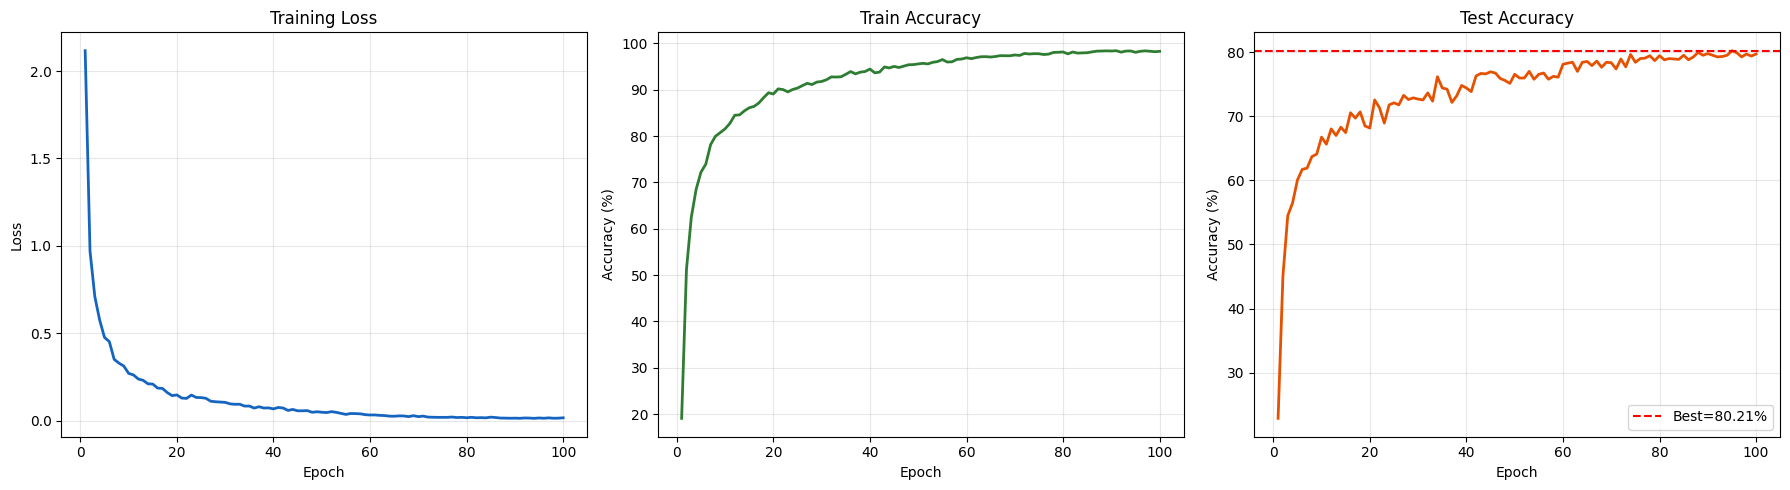

In [ ]:
# Plot training curves: loss, train accuracy, test accuracy
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, EPOCHS + 1)

# training loss: does the model's errors decrease over time?
# A smooth downward trend indicates stable learning.
# LR too low: if loss plateaus early
# LR too high or unstable training: if loss spikes or oscillates.
axes[0].plot(ep, train_losses, "#1565C0", lw=2)
axes[0].set(title="Training Loss", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

# training accuracy: how well does the model fit the training data?
# if training accuracy hits 100% but test accuracy is low - probably overfitting.
axes[1].plot(ep, train_accs, "#2E7D32", lw=2)
axes[1].set(title="Train Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].grid(alpha=0.3)

# training accuracy: how well does it perform on unseen data?
# the dashed red line marks the best test accuracy (from checkpoint saved in the training loop).
axes[2].plot(ep, test_accs, "#E65100", lw=2)
axes[2].axhline(max(test_accs), color="red", ls="--", label=f"Best={max(test_accs):.2f}%")
axes[2].set(title="Test Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[2].legend()
axes[2].grid(alpha=0.3)

# show the chart
plt.tight_layout()
plt.show()


# 7: Final evaluation & confusion matrix